In [46]:
!pip install numpy
!pip install pandas 
!pip install seaborn


In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv('/Users/phuongnguyen/Downloads/data3.csv')
df

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,reviews_count_y,playtime,platforms,stores,id_games,achievements_count,a_count,series_count,dev_team_count
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,216.0,0.0,"['PC', 'Linux']",['Steam'],965470,0.0,0.0,0.0,1.0
1,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,5.0,7.0,"['PC', 'macOS', 'Linux']",['Steam'],994601,0.0,0.0,1.0,1.0
2,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,635.0,24.0,"['PC', 'PlayStation 5', 'PlayStation 4', 'Xbox...","['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0
3,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,2439.0,5.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0
4,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,2128.0,8.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...","['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7454,https://store.steampowered.com/app/1446350/You...,You Will Die Here Tonight,2023-10-31,Spiral Bound Interactive LLC,"['Action', 'Adventure', 'Indie', 'RPG']","19,50€",0%,1.0,"['Dark', 'Psychological Horror', 'Zombies', 'C...",0.00,1.0,10.0,['PC'],"['Steam', 'GOG']",968736,15.0,0.0,0.0,0.0
7455,https://store.steampowered.com/app/1298140/Fob...,Fobia - St. Dinfna Hotel,2022-06-28,Pulsatrix Studios,['Indie'],"24,99€",0%,0.0,"['Indie', 'Survival Horror', 'Puzzle', 'Violen...",3.27,15.0,4.0,"['PC', 'Xbox One', 'PlayStation 4', 'Xbox Seri...","['Steam', 'itch.io']",484814,23.0,0.0,0.0,0.0
7456,https://store.steampowered.com/app/1161490/Mot...,MotoGP™20,2020-04-23,Milestone S.r.l.,"['Racing', 'Simulation', 'Sports']","19,99€",0%,1.0,"['Racing', 'Sports', 'Simulation', 'Motorbike'...",3.38,21.0,4.0,"['PC', 'Xbox One', 'PlayStation 4', 'Nintendo ...","['Steam', 'PlayStation Store', 'Xbox Store', '...",413881,54.0,0.0,14.0,0.0
7457,https://store.steampowered.com/app/1611430/The...,The Bridge Curse Road to Salvation,2022-08-24,SOFTSTAR ENTERTAINMENT,"['Action', 'Adventure', 'RPG']","16,79€",0%,1.0,"['Horror', 'First-Person', 'Puzzle', 'Explorat...",0.00,2.0,3.0,"['PC', 'PlayStation 5', 'Xbox One', 'PlayStati...","['Steam', 'PlayStation Store', 'Xbox Store', '...",840800,22.0,0.0,1.0,0.0


In [50]:
df.duplicated().sum()

36

In [51]:
df = df.drop_duplicates()
df.duplicated().sum()

0

мы хотим посчитать “успех игры”, но напрямую его нет в данных
поэтому собираем его из двух вещей: сколько людей играли и понравилась ли им игра, поэтому берем отзывы как основу, потому что они показывают, сколько людей реально играли, а это главный признак успеха, а рейтинг добавляем с меньшим весом, чтобы учитывать качество, но не считать успешной игру, в которую почти никто не играл

In [52]:
df['reviews_log'] = np.log1p(df['reviews_count_y']) # берем логарифм отзывов, чтобы убрать перекос из-за больших значений
df['reviews_norm'] = df['reviews_log'] / df['reviews_log'].max() # нормируем
df['rating_norm'] = df['rating'] / df['rating'].max() #  нормируем рейтинг, чтобы он был в той же шкале, что и отзывы
df['score'] = 0.65 * df['reviews_norm'] + 0.35 * df['rating_norm']

/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykernel_37737/1041197847.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reviews_log'] = np.log1p(df['reviews_count_y']) # берем логарифм отзывов, чтобы убрать перекос из-за больших значений
/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykernel_37737/1041197847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['reviews_norm'] = df['reviews_log'] / df['reviews_log'].max() # нормируем
/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykerne

In [53]:
df

,link,name,release_date,developers,genre,price,discount,dlc,tags,rating,...,stores,id_games,achievements_count,a_count,series_count,dev_team_count,reviews_log,reviews_norm,rating_norm,score
0,https://store.steampowered.com/app/730/Counter...,Counter-Strike 2,2012-08-21,Valve,"['Action', 'Free To Play']",Free To Play,0%,1.0,"['FPS', 'Shooter', 'Multiplayer', 'Competitive...",3.57,...,['Steam'],965470,0.0,0.0,0.0,1.0,5.379897,0.604780,0.739130,0.651803
1,https://store.steampowered.com/app/2868840/Sla...,Slay the Spire 2,2026-03-05,Mega Crit,"['Indie', 'Strategy', 'Early Access']","22,99€",0%,0.0,"['Strategy', 'Roguelike', 'Card Game', 'Deckbu...",0.00,...,['Steam'],994601,0.0,0.0,1.0,1.0,1.791759,0.201420,0.000000,0.130923
2,https://store.steampowered.com/app/2050650/Res...,Resident Evil 4,2023-03-24,"CAPCOM Co., Ltd.","['Action', 'Adventure']","100,24€",-60%,27.0,"['Horror', 'Action', 'Survival Horror', 'Third...",4.58,...,"['Steam', 'PlayStation Store']",795632,34.0,0.0,28.0,7.0,6.455199,0.725660,0.948240,0.803563
3,https://store.steampowered.com/app/1172470/Ape...,Apex Legends™,2020-11-04,Respawn,"['Action', 'Adventure', 'Free To Play']",Free To Play,0%,0.0,"['Free to Play', 'Battle Royale', 'Multiplayer...",3.63,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",290856,12.0,21.0,1.0,3.0,7.799753,0.876807,0.751553,0.832968
4,https://store.steampowered.com/app/230410/Warf...,Warframe,2013-03-25,Digital Extremes,"['Action', 'RPG', 'Free To Play']",Free To Play,0%,17.0,"['Free to Play', 'Looter Shooter', 'Action RPG...",3.42,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",766,259.0,0.0,0.0,14.0,7.663408,0.861480,0.708075,0.807788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7454,https://store.steampowered.com/app/1446350/You...,You Will Die Here Tonight,2023-10-31,Spiral Bound Interactive LLC,"['Action', 'Adventure', 'Indie', 'RPG']","19,50€",0%,1.0,"['Dark', 'Psychological Horror', 'Zombies', 'C...",0.00,...,"['Steam', 'GOG']",968736,15.0,0.0,0.0,0.0,0.693147,0.077920,0.000000,0.050648
7455,https://store.steampowered.com/app/1298140/Fob...,Fobia - St. Dinfna Hotel,2022-06-28,Pulsatrix Studios,['Indie'],"24,99€",0%,0.0,"['Indie', 'Survival Horror', 'Puzzle', 'Violen...",3.27,...,"['Steam', 'itch.io']",484814,23.0,0.0,0.0,0.0,2.772589,0.311680,0.677019,0.439548
7456,https://store.steampowered.com/app/1161490/Mot...,MotoGP™20,2020-04-23,Milestone S.r.l.,"['Racing', 'Simulation', 'Sports']","19,99€",0%,1.0,"['Racing', 'Sports', 'Simulation', 'Motorbike'...",3.38,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",413881,54.0,0.0,14.0,0.0,3.091042,0.347479,0.699793,0.470789
7457,https://store.steampowered.com/app/1611430/The...,The Bridge Curse Road to Salvation,2022-08-24,SOFTSTAR ENTERTAINMENT,"['Action', 'Adventure', 'RPG']","16,79€",0%,1.0,"['Horror', 'First-Person', 'Puzzle', 'Explorat...",0.00,...,"['Steam', 'PlayStation Store', 'Xbox Store', '...",840800,22.0,0.0,1.0,0.0,1.098612,0.123500,0.000000,0.080275


Одномерный анализ признаков


 platforms и stores лежат как текстовые списки и ихнадо превратить в числовые признаки, будем считать количество платформ и количество магазинов, на которых есть игра
 

In [63]:

#функция проверяет, является ли значение строкой со списком, и если да, то считает, сколько элементов в этом списке
def get_len(x):
    if not isinstance(x, str):
        return 0

    x = x.strip()

    if x == "[]":
        return 0

    if x.startswith("[") and x.endswith("]"):
        inside = x[1:-1].strip()

        if inside == "":
            return 0

        return len(inside.split(","))

    return 0

In [64]:
df['platforms_count'] = df['platforms'].apply(get_len)
df['stores_count'] = df['stores'].apply(get_len)

/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykernel_37737/3180246236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['platforms_count'] = df['platforms'].apply(get_len)
/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykernel_37737/3180246236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['stores_count'] = df['stores'].apply(get_len)


In [67]:
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykernel_37737/3715443266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_date'] = pd.to_datetime(df['release_date'])
/var/folders/0j/dnzrb48j1wb4yxvy9btn88_r0000gn/T/ipykernel_37737/3715443266.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['release_year'] = df['release_date'].dt.year


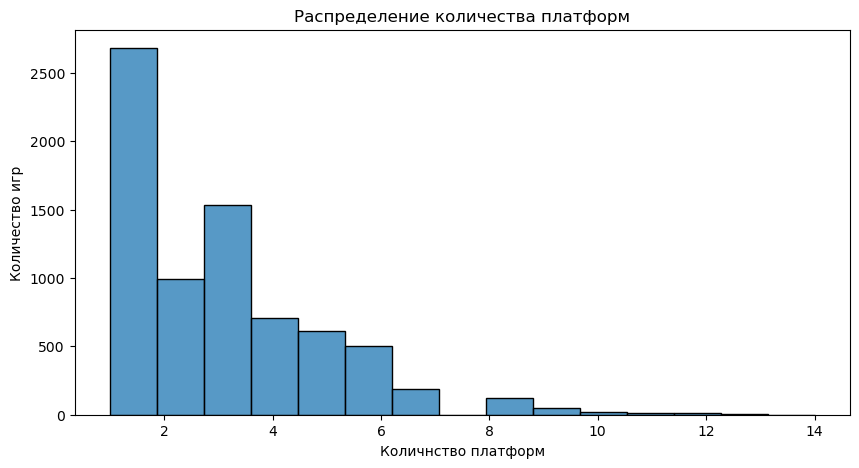

In [75]:
plt.figure(figsize=(10, 5))
sns.histplot(df['platforms_count'], bins=15)
plt.xlabel('Количнство платформ')
plt.ylabel('Количество игр')
plt.title('Распределение количества платформ')
plt.show()

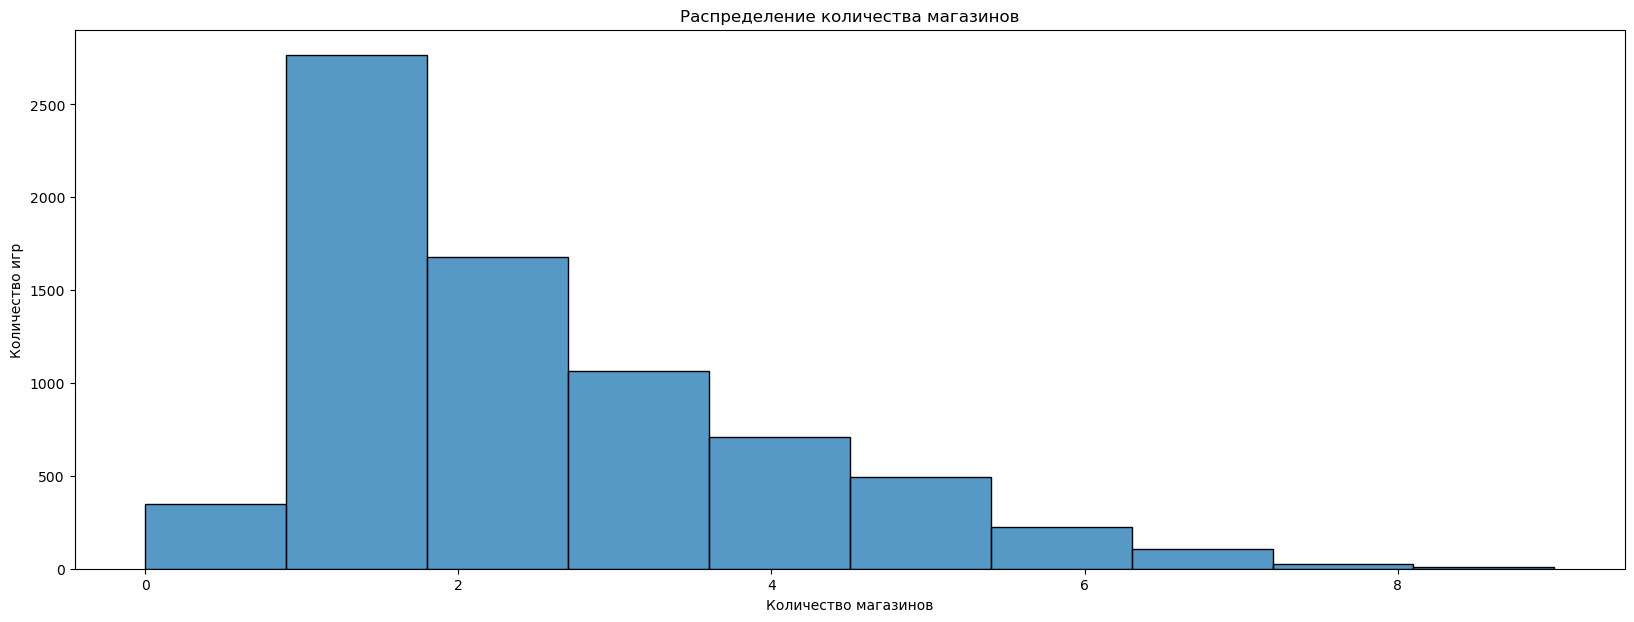

<Figure size 1000x500 with 0 Axes>

In [78]:
sns.histplot(df['stores_count'], bins=10)
plt.title('Распределение количества магазинов')
plt.xlabel('Количество магазинов')
plt.ylabel('Количество игр')
plt.figure(figsize=(10, 5))
plt.show()

Text(0.5, 1.0, 'Распределение по годам выпуска')

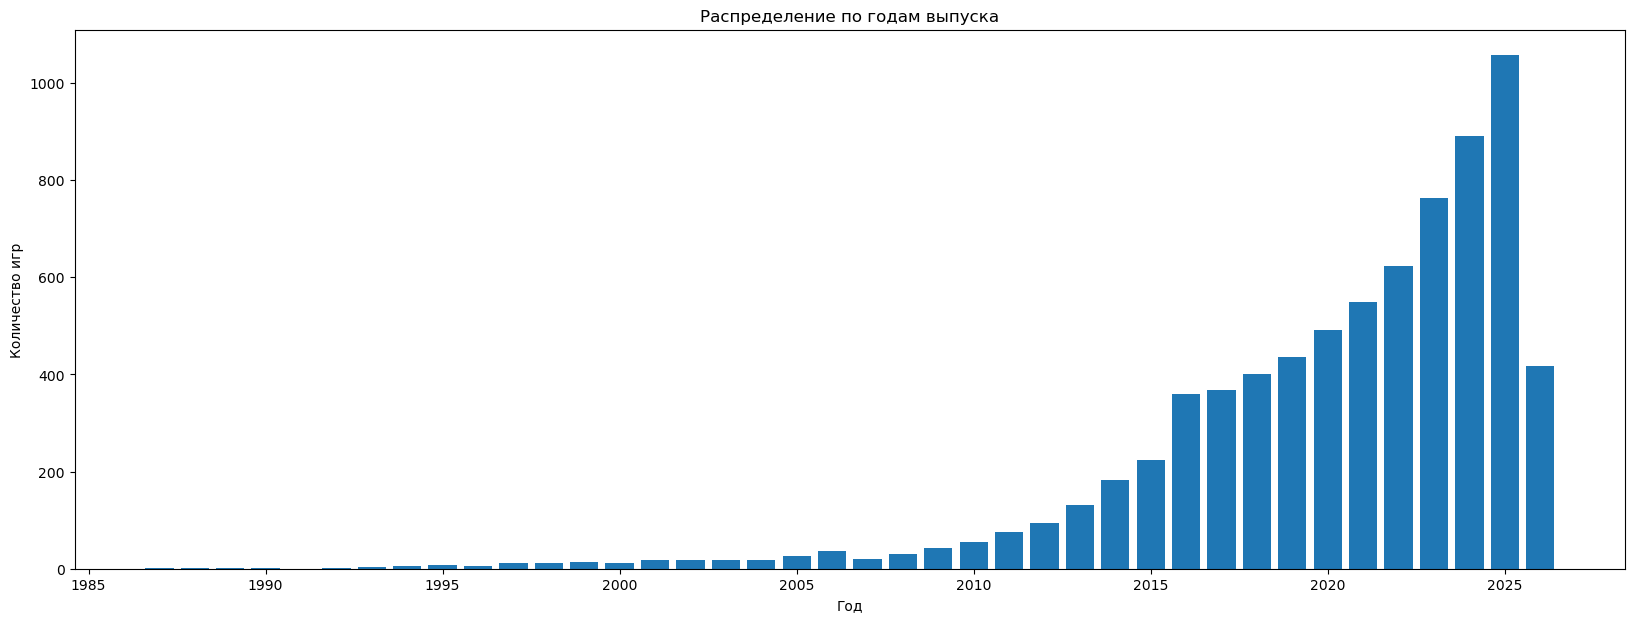

In [107]:

kol_v_god = df.groupby('release_year')['name'].count().reset_index()
kol_v_god.columns = ['year', 'number_of_games']
plt.bar(kol_v_god['year'],kol_v_god['number_of_games'] )
plt.xlabel('Год')
plt.ylabel('Количество игр')
plt.title('Распределение по годам выпуска')


Сформулирую гипотезы
1) Чем больше платформ, на которых доступна игра, тем выше ее успешность
2) Чем больше магазинов, в которых доступна игра, тем выше ее успешность
3) Дата релиза связана с успешностью игры

Гипотеза 1



In [109]:
platform_summary = df.groupby('platforms_count')['score'].agg(['count', 'mean', 'median']).reset_index()
platform_summary

,platforms_count,count,mean,median
0,1,2681,0.281705,0.263201
1,2,995,0.408835,0.464993
2,3,1531,0.497734,0.552777
3,4,709,0.541053,0.559006
4,5,611,0.594279,0.622778
5,6,500,0.608863,0.631788
6,7,189,0.648407,0.686780
7,8,119,0.666475,0.692528
8,9,49,0.707352,0.728492
9,10,17,0.717138,0.701393


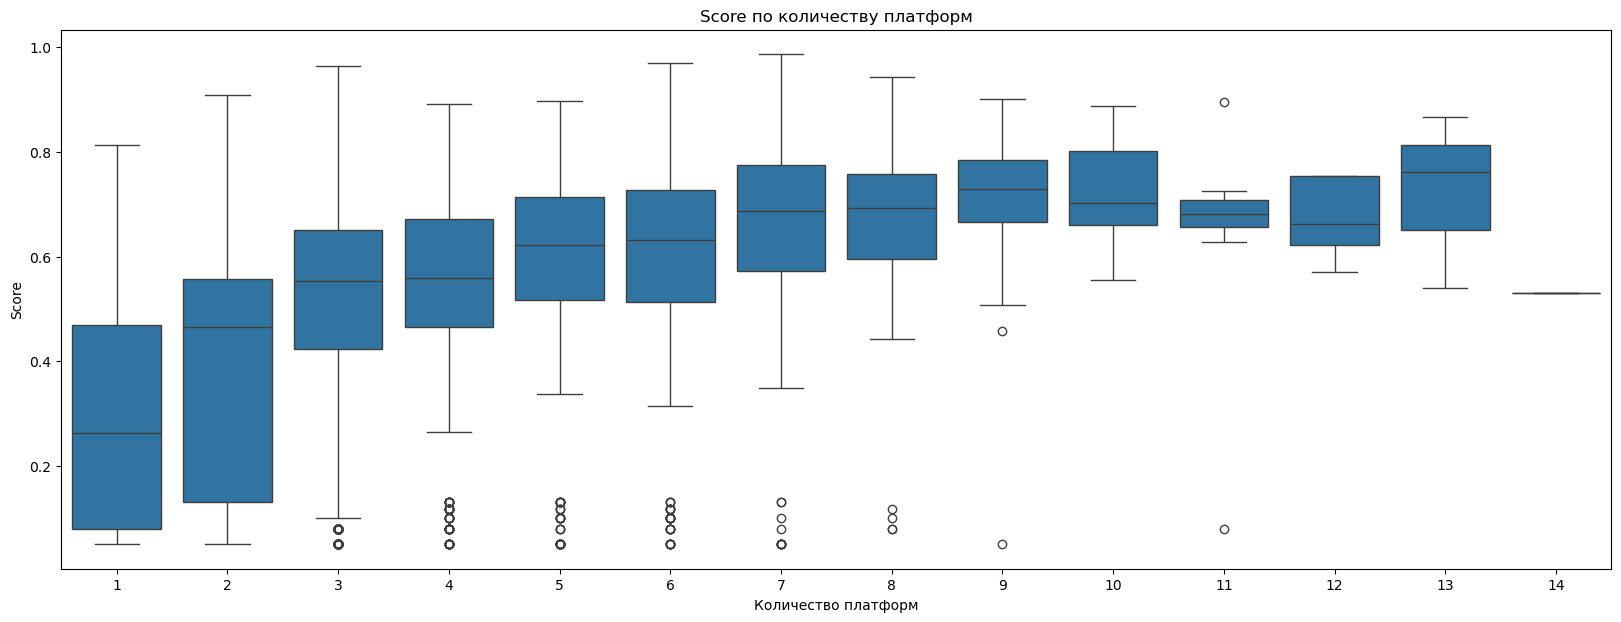

In [112]:

sns.boxplot(data=df, x='platforms_count', y='score')
plt.title('Score по количеству платформ')
plt.xlabel('Количество платформ')
plt.ylabel('Score')
plt.show()

В целом, с ростом количества платформ score у игр тоже растет и можно сказать, что многоплатформные игры имеют более высокий уровень успешности. Но при этом для групп с очень большим числом платформ выборка довольно мала, в некоторых невероятно мала, поэтому вывод для них менее надежен

Гипотеза 2 

In [115]:
store_summary = df.groupby('stores_count')['score'].agg(['count', 'mean', 'median']).reset_index()
print(store_summary)

   stores_count  count      mean    median
0             0    350  0.363788  0.442162
1             1   2764  0.297393  0.328192
2             2   1678  0.425269  0.478708
3             3   1062  0.539206  0.554832
4             4    707  0.607746  0.623172
5             5    493  0.644206  0.658152
6             6    226  0.672779  0.672563
7             7    108  0.722720  0.731843
8             8     27  0.707581  0.719976
9             9      8  0.801834  0.833129


In [116]:
print(df[['score', 'stores_count']].corr())

                 score  stores_count
score         1.000000      0.517575
stores_count  0.517575      1.000000


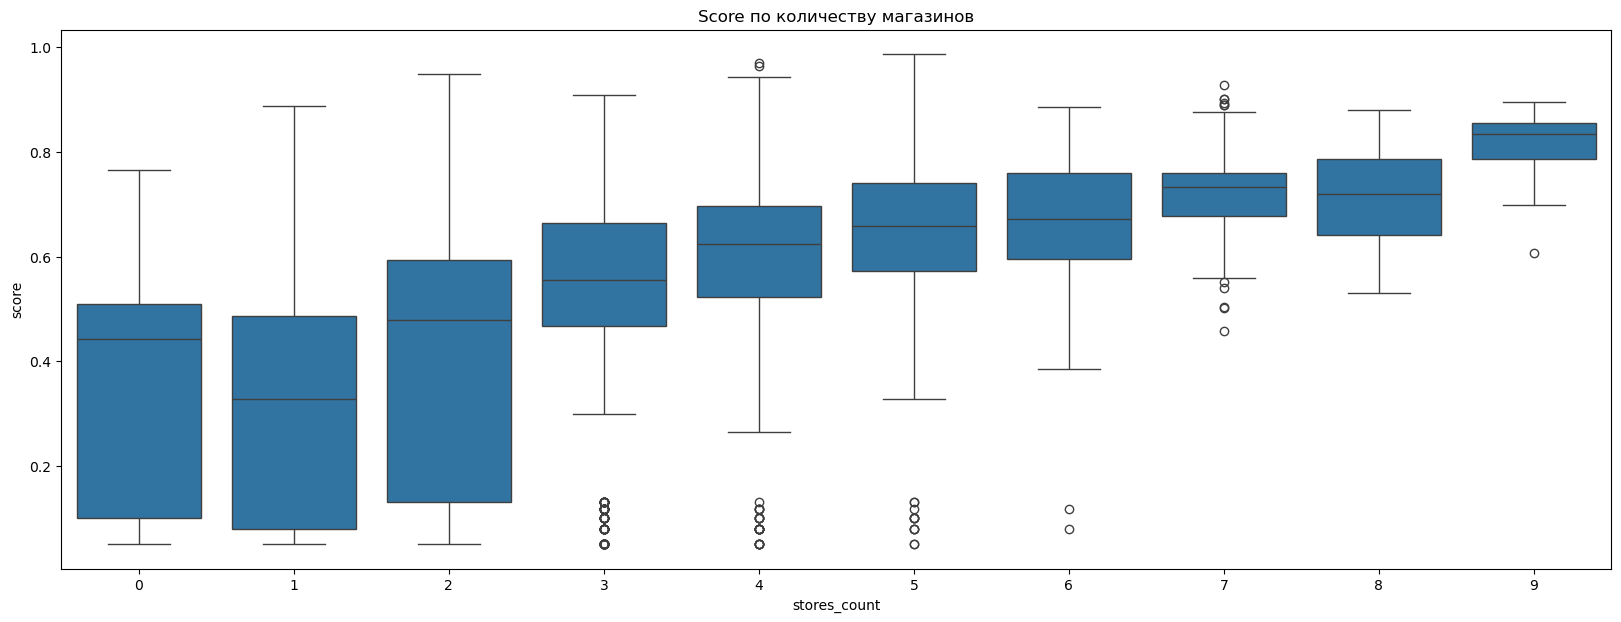

In [117]:
sns.boxplot(data=df, x='stores_count', y='score')
plt.title('Score по количеству магазинов')
plt.xlabel('stores_count')
plt.ylabel('score')
plt.show()

Есть положительная зависимость между количеством магазинов и значением score. Это видно и по boxplot и по таблице кореляция

Гипотеза 3

In [129]:
year_summary = df.groupby('release_year')['score'].agg(['count', 'mean', 'median']).reset_index()
print(year_summary)

    release_year  count      mean    median
0           1987      1  0.101296  0.101296
1           1988      1  0.549579  0.549579
2           1989      2  0.285983  0.285983
3           1990      2  0.329960  0.329960
4           1992      2  0.547284  0.547284
5           1993      3  0.617626  0.634173
6           1994      5  0.577665  0.566588
7           1995      8  0.516741  0.569517
8           1996      5  0.578183  0.550341
9           1997     12  0.578134  0.626882
10          1998     11  0.570239  0.607816
11          1999     13  0.598782  0.635926
12          2000     12  0.582863  0.613858
13          2001     17  0.656357  0.669182
14          2002     17  0.596756  0.646521
15          2003     17  0.645005  0.625401
16          2004     18  0.707097  0.708431
17          2005     26  0.627300  0.679946
18          2006     36  0.565625  0.587975
19          2007     19  0.576674  0.654085
20          2008     31  0.613599  0.658852
21          2009     42  0.62596

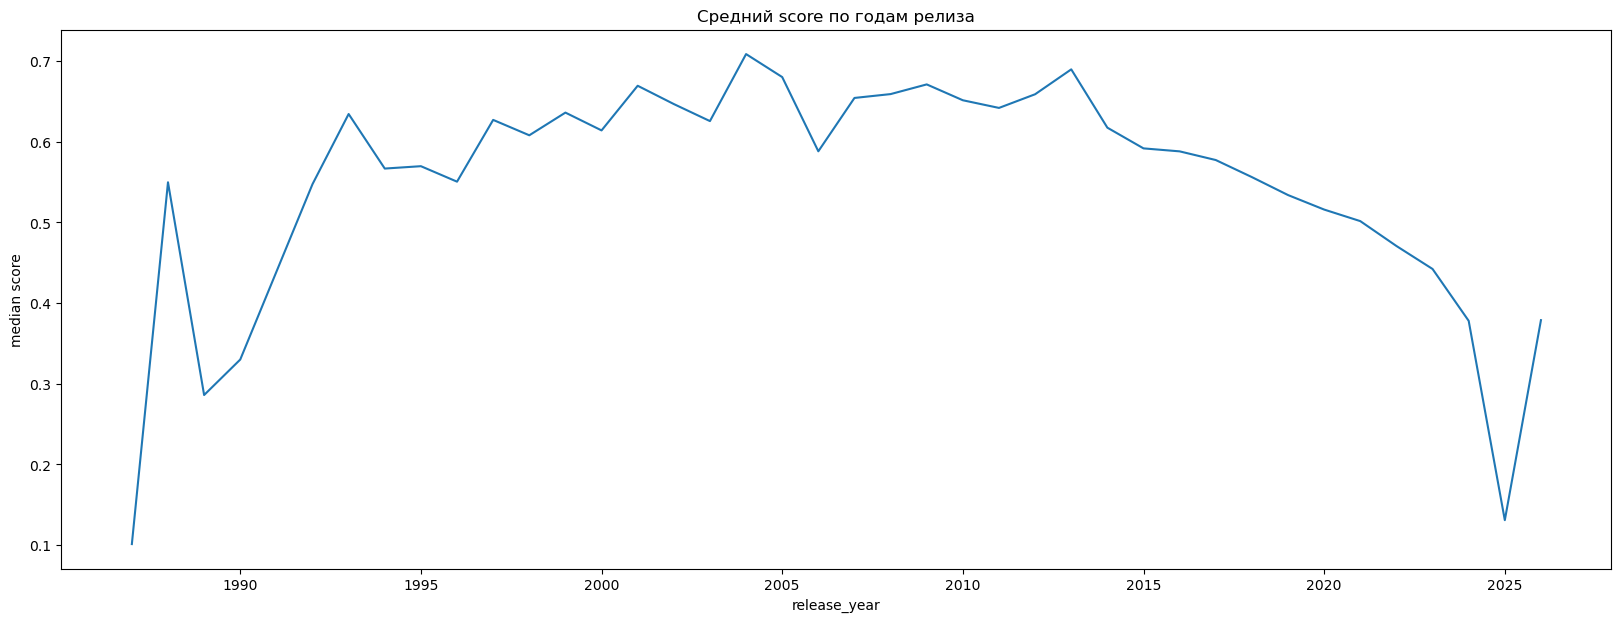

In [135]:
sns.lineplot(data=year_summary, x='release_year', y='median')
plt.xlabel('release_year')
plt.ylabel('median score')
plt.title('Средний score по годам релиза')
plt.show()

Год выпуска связан со score, но нелинейно. У самых ранних и самых поздних лет значения могут сильно прыгать из-за малого числа игр в этих группах

<Axes: >

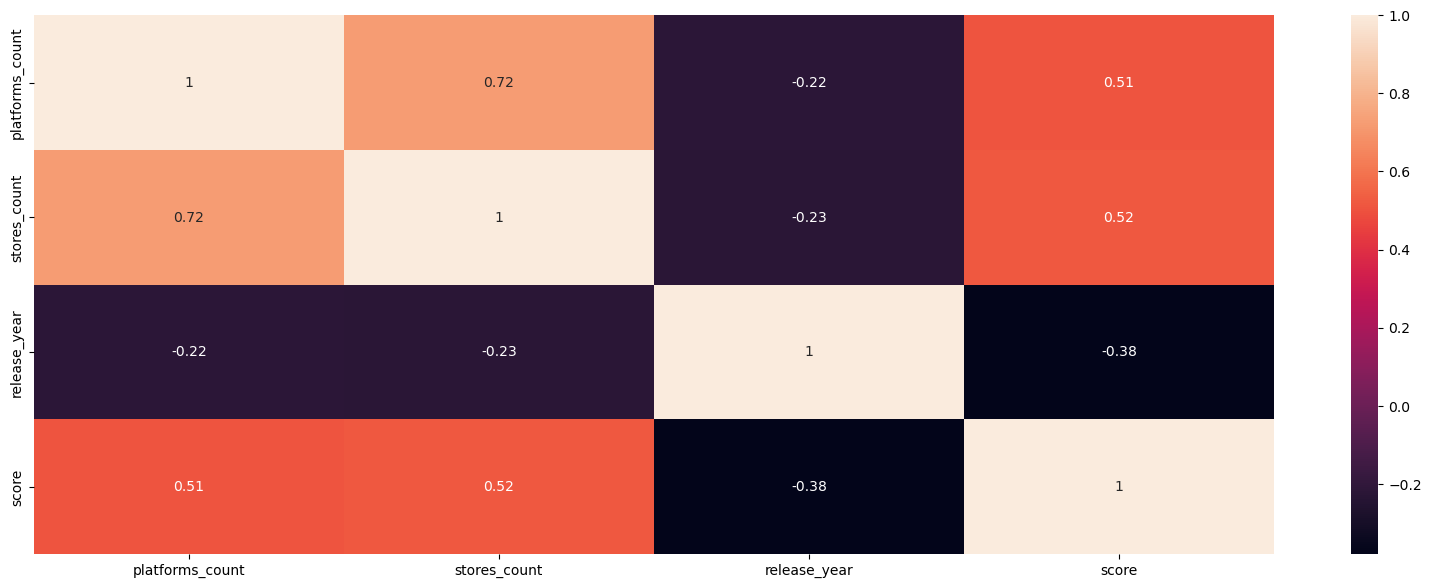

In [158]:
sns.heatmap(df[['platforms_count', 'stores_count', 'release_year', 'score']].corr(), annot = True)
